In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("IMDB Dataset.csv",engine='python') # Replace with your file path

In [9]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
texts = data['review'].astype(str).values
labels = data['sentiment'].values

In [11]:
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

In [12]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
padded_sequences, labels, test_size=0.2, random_state=42)

In [14]:
model = Sequential([
Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
LSTM(64, return_sequences=False),
Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5726 - loss: 0.6590 - val_accuracy: 0.8309 - val_loss: 0.4457
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7541 - loss: 0.4977 - val_accuracy: 0.7005 - val_loss: 0.6310
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7739 - loss: 0.4885 - val_accuracy: 0.7886 - val_loss: 0.4976
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6971 - loss: 0.5724 - val_accuracy: 0.5817 - val_loss: 0.6584
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7228 - loss: 0.5419 - val_accuracy: 0.5014 - val_loss: 1.1307
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6283 - loss: 0.6551 - val_accuracy: 0.8583 - val_loss: 0.3568
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9006 - loss: 0.2645 - val_accuracy: 0.8702 - val_loss: 0.3065
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9210 - loss: 0.2153 - val_

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8775 - loss: 0.3374
Test Accuracy: 0.8777


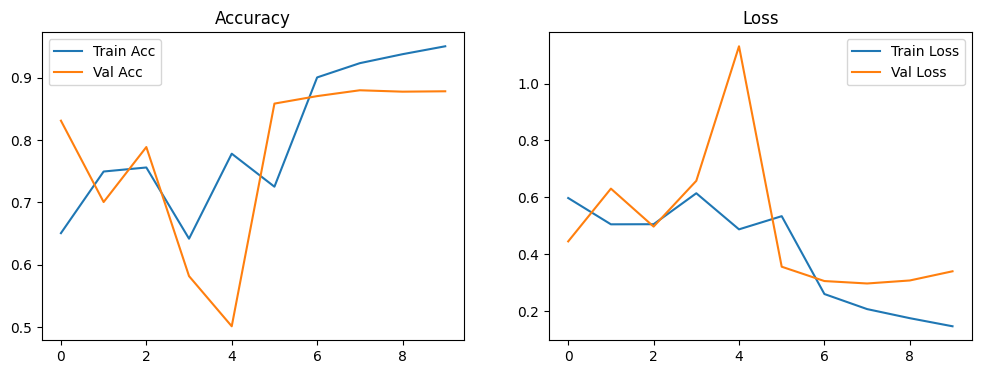

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


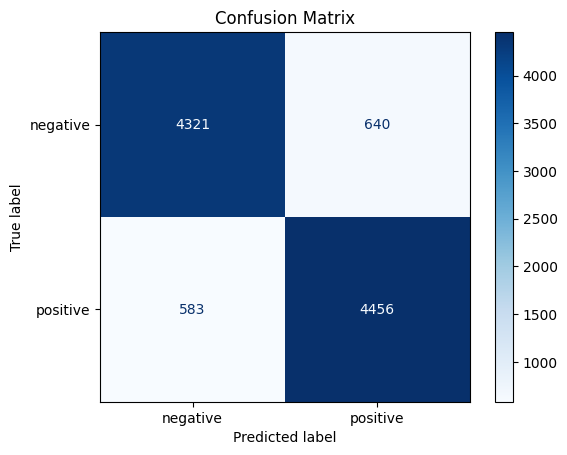

In [18]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()